# Multi-object segmentation on a single tif

End-to-end example using `sam2_utils`:

1. Set up SAM2 (device, autocast, model, predictor)
2. Pull annotations from CATMAID and apply the stack→tif affine
3. Pick a z-section, downscale image + points for SAM2, run prediction
4. Save masks to disk at full-res, overlay at SAM2 resolution

Knobs sit at the top — change those, re-run.

**Memory notes (v2):** masks are upscaled and written one-at-a-time inside a
loop instead of being stacked into a 4 GB array. The overlay is rendered on
the SAM2-scale image, not the full-res tif. Both changes together free ~7 GB
of peak RAM on a 9k×9k input. If 21 GB still feels tight, try `SCALE=8`.

## Top-level knobs

In [1]:
# ==== SETUP KNOBS =====================================================
TARGET_Z   = 1293                                   # CATMAID z-section to segment
SCALE      =  8                                     # downsample factor for SAM2 (1 = full-res, 4 = quarter, 8 = ~native SAM2 input)
MODEL_SIZE = "large"                                # tiny / small / base_plus / large
SAVE_DOWNSCALE = 4                                  # save masks at full-res / N (1 = full-res, 2 = half, 4 = quarter)
OUT_DIR    = r"E:\ZhenLab\Data\output_masks\test2_single"
# ================================================================

# ==== negative-filtering knobs =====================================
K_MAX_NEG   = 10     # max negatives per object
NEG_RADIUS  = 150   # exclusion radius in SAM2-resolution pixels
# ===================================================================

## 1. Setup: device, model, predictor

`build_predictor` handles everything: picks CUDA/MPS/CPU, enters bfloat16 autocast,
downloads the checkpoint if missing, and returns a ready-to-use `SAM2ImagePredictor`.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import cv2
import matplotlib.pyplot as plt

from sam2_utils import setup, viz, diagnostics, catmaid, alignment, config

predictor, device = setup.build_predictor(size=MODEL_SIZE, kind="image")
diagnostics.snapshot("after model load")

PyTorch: 2.12.0+cu130
CUDA available: True
Using device: cuda
Checkpoint already present: checkpoints\sam2.1_hiera_large.pt


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sam2\modeling\position_encoding.py:96: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  torch.arange(1, H + 1, dtype=torch.float32, device=device)



  Snapshot: after model load
  [RAM]       used=14.57 GB / total=21.17 GB
  [Pagefile]  used=18.07 GB / total=42.34 GB
  [VRAM]      allocated=0.98 GB  reserved=1.03 GB
  [Disk] notebook dir:       1120.59 MB  (D:\Zhen Lab\SAM2 Segmentation\segmentation-playground)
  [Disk] .ipynb_checkpoints: 0.00 MB
  [Disk] Jupyter runtime:    801.16 MB
  [Disk] system temp:        802.14 MB
  [Files] open handles: 22
       0.01 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\vscode.git\Git.log
       4.30 MB  C:\Users\User\.ipython\profile_default\history.sqlite
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\mechatroner.rainbow-csv\rainbow_csv_debug_channel.log
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\output_logging_20260527T113851\5-GitHub Copilot Log (Code References).log
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\GitHub.copilot-chat\Gi

## 2. CATMAID annotations

Pulls every skeleton's nodes, converts nm → stack-pixel coords, and applies the
fitted affine so points actually land on the right cells in the tif.

The first pull is slow (one HTTP call per cell, ~2 min for 386 skeletons). If
you'll re-run this notebook, uncomment the `%store` line below, then on later
runs you can restore from cache and skip the pull entirely:

```python
# After first successful pull:
%store aggregate_data_pv

# Later runs — replace the pull cell with:
%store -r aggregate_data_pv
```

In [3]:
# Pull full annotations DataFrame (uses CATMAID_TOKEN from env / .env)
# cm = catmaid.Catmaid()
# aggregate_data_pv = catmaid.fetch_all_annotations(cm)
# %store aggregate_data_pv        # uncomment after first successful pull
%store -r aggregate_data_pv
aggregate_data_pv.head()

,node_id,parent_id,confidence,x,y,z,radius,creator_id,edition_time,cell_name,is_vnode
0,25499312,25499311.0,5,4679.15,3122.6,13.0,-1.0,128,1764016218.0,A49L,False
1,25499311,25499310.0,5,4683.15,3140.6,14.0,-1.0,128,1764016217.0,A49L,False
2,25490621,25490620.0,5,3504.855,3103.72,15.0,-1.0,128,1763348949.0,A30R,False
3,25499310,25499309.0,5,4779.15,3146.6,15.0,-1.0,128,1764016216.0,A49L,False
4,25494113,25494112.0,5,4265.15,4838.6,15.0,-1.0,128,1763579295.0,hyp1?,False


In [4]:
# Apply the stack -> tif affine once, store as new columns
xy_tif = alignment.catmaid_to_tif(aggregate_data_pv["x"].values,
                                  aggregate_data_pv["y"].values)
aggregate_data_pv["x_tif"] = xy_tif[:, 0]
aggregate_data_pv["y_tif"] = xy_tif[:, 1]

# Filter to the target z-section
annotate = aggregate_data_pv[aggregate_data_pv["z"] == TARGET_Z].reset_index(drop=True)
print(f"z={TARGET_Z}: {len(annotate)} annotation nodes")
annotate.head()

z=1293: 108 annotation nodes


,node_id,parent_id,confidence,x,y,z,radius,creator_id,edition_time,cell_name,is_vnode,x_tif,y_tif
0,25530192,v_25530192_1294,5,2142.15,4069.61,1293.0,-1.0,128,1767376362.0,AUAR,False,1651.069888,4049.174173
1,25396484,25396483.0,5,3983.805,6372.95,1293.0,-1.0,128,1757138252.0,hyp6,False,3794.127261,6559.764275
2,v_25532073_1293,v_25532073_1293,NaN,2812.296154,2989.209231,1293,NaN,NaN,NaN,BWM-DR04,True,2358.811337,2815.708455
3,v_25483907_1293,v_25483907_1293,NaN,2864.15,3172.2,1293,NaN,NaN,NaN,OLLsoR?,True,2423.589934,3018.603596
4,v_25545336_1293,v_25545336_1296,NaN,6378.0,5430.1,1293,NaN,NaN,NaN,BWM-VL04,True,6432.230117,5417.457629


## 3. Load matching tif, scale image + points

Files are named by file-z, which differs from CATMAID z by `FILE_Z_OFFSET` (−7).
We resolve the file by parsing its `zNNNN` token, then downscale by `SCALE` for SAM2.

`H_full, W_full` are captured so we can upscale individual masks back to full-res
inside the save loop — without ever holding the full-res image alongside them.

In [5]:
# Find the tif for this CATMAID z. Filenames look like "1301____z1300.0.tif";
# file_z = CATMAID_z - FILE_Z_OFFSET  (offset is -7, so file_z = CATMAID_z + 7).
target_file_z = TARGET_Z - config.FILE_Z_OFFSET
tif_files = sorted(config.WORM_PATH.glob("*.tif"))

def parse_file_z(p: Path) -> int:
    # ".../1301____z1300.0.tif"  ->  1300
    token = p.stem.split("z")[-1]
    return int(float(token))

matches = [f for f in tif_files if parse_file_z(f) == target_file_z]
assert len(matches) == 1, f"Expected 1 tif for file_z={target_file_z}, got {len(matches)}: {matches}"
tif_path = matches[0]
print(f"Loading {tif_path.name}  (file_z={target_file_z}, CATMAID_z={TARGET_Z})")

image_full = cv2.imread(str(tif_path))
image_full = cv2.cvtColor(image_full, cv2.COLOR_BGR2RGB)
H_full, W_full = image_full.shape[:2]
print(f"Full-res shape: {image_full.shape}")
diagnostics.snapshot("after image load")

Loading 1301____z1300.0.tif  (file_z=1300, CATMAID_z=1293)
Full-res shape: (9216, 9230, 3)

  Snapshot: after image load
  [RAM]       used=14.73 GB / total=21.17 GB
  [Pagefile]  used=18.78 GB / total=42.34 GB
  [VRAM]      allocated=0.98 GB  reserved=1.03 GB
  [Disk] notebook dir:       1120.59 MB  (D:\Zhen Lab\SAM2 Segmentation\segmentation-playground)
  [Disk] .ipynb_checkpoints: 0.00 MB
  [Disk] Jupyter runtime:    803.50 MB
  [Disk] system temp:        803.64 MB
  [Files] open handles: 22
       0.01 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\vscode.git\Git.log
       4.30 MB  C:\Users\User\.ipython\profile_default\history.sqlite
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\mechatroner.rainbow-csv\rainbow_csv_debug_channel.log
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\output_logging_20260527T113851\5-GitHub Copilot Log (Code References).log
       0.00 MB  C:\

In [6]:
# Helpers for SCALE knob: image + points down, single mask back up
def downscale_image(img, scale):
    if scale == 1:
        return img.copy()
    return cv2.resize(img, None, fx=1/scale, fy=1/scale, interpolation=cv2.INTER_AREA)

def downscale_points(xy_full, scale):
    return np.asarray(xy_full, dtype=float) / scale

def upscale_mask(mask, target_hw, scale):
    if scale == 1:
        return mask.astype(np.uint8)
    H, W = target_hw
    # nearest-neighbour preserves binary edges
    return cv2.resize(mask.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)

image_sam = downscale_image(image_full, SCALE)
H_sam, W_sam = image_sam.shape[:2]
print(f"SAM2 input shape: {image_sam.shape}  (downscaled {SCALE}x from full)")

# Free the full-res image now — we only need (H_full, W_full) for upscaling later.
# Re-read from disk in the save loop. Costs ~1s per re-read; saves ~240 MB peak RAM.
del image_full

SAM2 input shape: (1152, 1154, 3)  (downscaled 8x from full)


## 4. Build multi-object point prompts

SAM2 multi-object input expects `(N_objects, N_points_per_object, 2)` plus matching
labels `(N_objects, N_points_per_object)`. One positive point per object: the
CATMAID node's location. (To add a negative point per object, append a second
`[x, y]` and a `0` label.)

We select a few negative prompts using a filtered k-nearest neighbors algorithm.

In [7]:
from scipy.spatial import cKDTree

# x_tif / y_tif are at full-res. Downscale them to SAM2 space.
points_full = annotate[["x_tif", "y_tif"]].values     # (N, 2) at full-res
points_sam  = downscale_points(points_full, SCALE)    # (N, 2) at SAM2 res
N = len(points_sam)

tree = cKDTree(points_sam)

# Build per-row prompts of varying length, then pad to a common width.
rows_points = []
rows_labels = []
n_neg_used = []

for i in range(N):
    # Query k+1 because the closest hit will be the point itself
    dists, idxs = tree.query(points_sam[i], k=min(K_MAX_NEG + 1, N))
    # Drop self (distance 0)
    keep = [(d, j) for d, j in zip(dists, idxs) if j != i and d <= NEG_RADIUS]
    keep = keep[:K_MAX_NEG]
    neg_pts = np.array([points_sam[j] for _, j in keep]) if keep else np.empty((0, 2))

    # Row: 1 positive (self) + 0..K_MAX_NEG negatives
    row_pts = np.vstack([points_sam[i:i+1], neg_pts])
    row_lbl = np.concatenate([[1], np.zeros(len(neg_pts), dtype=int)])
    rows_points.append(row_pts)
    rows_labels.append(row_lbl)
    n_neg_used.append(len(neg_pts))

# Pad to (N, max_points, 2) with the positive itself (label -1 means "ignore")
# SAM2 uses label -1 as a "padding" token, so this is safe.
max_pts = max(r.shape[0] for r in rows_points)
input_points = np.zeros((N, max_pts, 2), dtype=float)
input_labels = -np.ones((N, max_pts), dtype=int)
for i, (pts, lbl) in enumerate(zip(rows_points, rows_labels)):
    input_points[i, :len(pts)] = pts
    input_labels[i, :len(lbl)] = lbl

print(f"{N} objects, prompt shape {input_points.shape}, labels shape {input_labels.shape}")
print(f"negatives per object: min={min(n_neg_used)}, "
      f"mean={np.mean(n_neg_used):.1f}, max={max(n_neg_used)}")

108 objects, prompt shape (108, 11, 2), labels shape (108, 11)
negatives per object: min=2, mean=8.4, max=10


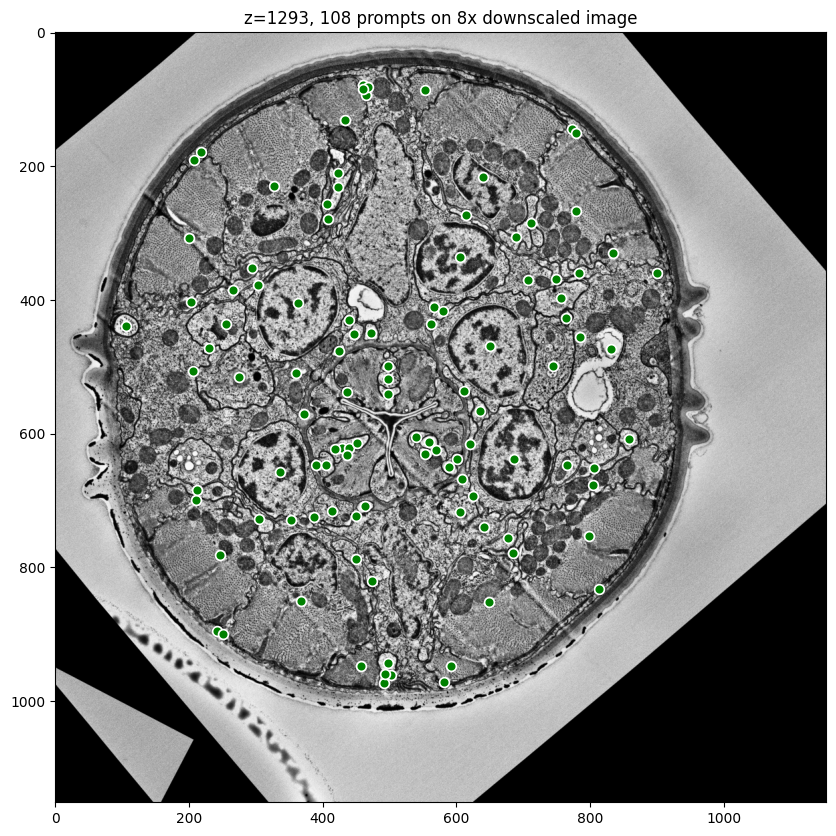

In [8]:
# Sanity overlay — points on the downscaled image we'll feed to SAM2
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image_sam)
viz.show_points(points_sam, np.ones(N), ax)
ax.set_title(f"z={TARGET_Z}, {N} prompts on {SCALE}x downscaled image")
plt.show()

## 5. Run multi-object prediction

Embedding + prediction inside `inference_mode` to keep autograd from accumulating
state across re-runs. Masks come back at SAM2 resolution and stay there — we
upscale per-mask only when saving.

In [9]:
with torch.inference_mode():
    predictor.set_image(image_sam)
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True,    # three candidates per object
    )

# masks:  (N, 3, H, W)  ->  pick best per object  ->  (N, H, W)
# scores: (N, 3)        ->  matching best score    ->  (N,)
best_idx = np.argmax(scores, axis=1)
masks  = masks[np.arange(len(masks)), best_idx]
scores = scores[np.arange(len(scores)), best_idx]

print(f"masks shape: {masks.shape}, scores shape: {scores.shape}")
print(f"score range: {scores.min():.3f} .. {scores.max():.3f}, mean {scores.mean():.3f}")
diagnostics.snapshot("after predict")

masks shape: (108, 1152, 1154), scores shape: (108,)
score range: 0.026 .. 0.953, mean 0.622

  Snapshot: after predict
  [RAM]       used=15.22 GB / total=21.17 GB
  [Pagefile]  used=24.60 GB / total=42.34 GB
  [VRAM]      allocated=1.00 GB  reserved=5.71 GB
  [Disk] notebook dir:       1120.59 MB  (D:\Zhen Lab\SAM2 Segmentation\segmentation-playground)
  [Disk] .ipynb_checkpoints: 0.00 MB
  [Disk] Jupyter runtime:    803.64 MB
  [Disk] system temp:        803.64 MB
  [Files] open handles: 23
       0.01 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\vscode.git\Git.log
       4.31 MB  C:\Users\User\.ipython\profile_default\history.sqlite
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\mechatroner.rainbow-csv\rainbow_csv_debug_channel.log
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\output_logging_20260527T113851\5-GitHub Copilot Log (Code References).log
       0.00 MB  C:\U

## 6. Overlay at SAM2 resolution

Rendered on the downscaled image; same as the prediction input. Looks identical
to a full-res overlay for sanity-checking purposes but uses WAYYY less memory

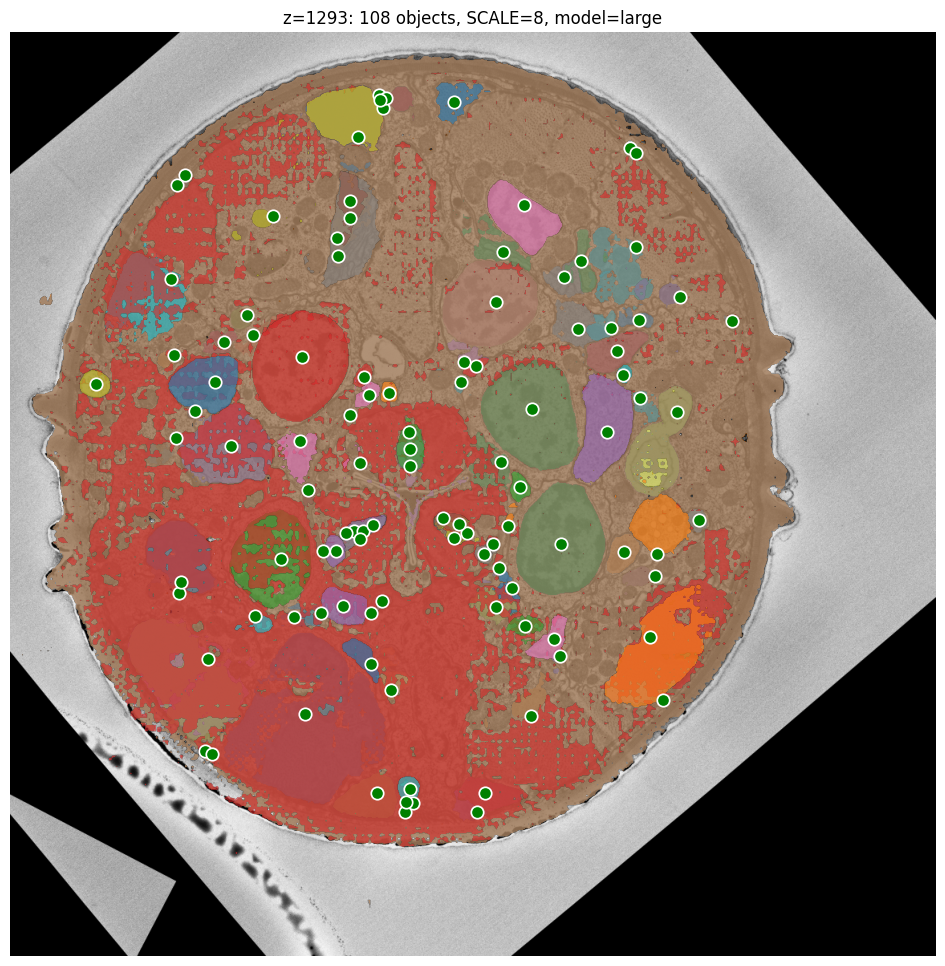

In [10]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(image_sam)
for i, m in enumerate(masks):                       # SAM2-res masks, not full-res
    viz.show_mask(m, ax, obj_id=i)
viz.show_points(points_sam, np.ones(N), ax, marker_size=80)
ax.set_title(f"z={TARGET_Z}: {N} objects, SCALE={SCALE}, model={MODEL_SIZE}")
ax.axis("off")
plt.show()

In [20]:
# ============ KNOBS ============
INSPECT_DATAFRAME = annotate         # df with x_tif, y_tif at full-res; also needs x, y (raw CATMAID)
INSPECT_IMAGE     = image_sam        # SAM2-res image
INSPECT_MASKS     = masks            # SAM2-res masks, shape (N, H_sam, W_sam)
INSPECT_SCORES    = scores           # shape (N,)
INSPECT_SCALE     = SCALE            # so we can map x_tif/y_tif into image_sam space
MAG               = 60              # window half-width in SAM2-pixel units (smaller = closer)
# ===============================

15

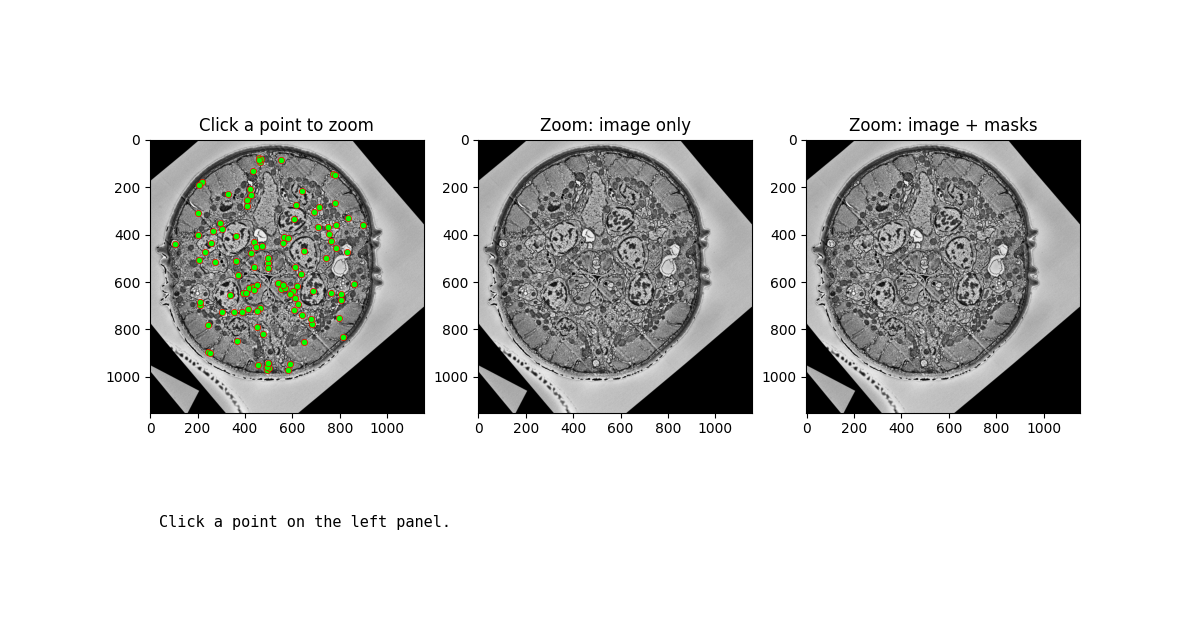

In [21]:
%matplotlib widget

# --- Setup: project full-res coords down to SAM2 space ---
xs_sam     = INSPECT_DATAFRAME["x_tif"].values / INSPECT_SCALE   # transformed prompt, SAM2-px
ys_sam     = INSPECT_DATAFRAME["y_tif"].values / INSPECT_SCALE
xs_cm_sam  = INSPECT_DATAFRAME["x"].values     / INSPECT_SCALE   # raw CATMAID, SAM2-px
ys_cm_sam  = INSPECT_DATAFRAME["y"].values     / INSPECT_SCALE
N_pts = len(INSPECT_DATAFRAME)
assert len(INSPECT_MASKS) == N_pts, (
    f"masks count ({len(INSPECT_MASKS)}) != dataframe rows ({N_pts}). "
    "Inspector assumes row i of the dataframe corresponds to masks[i]."
)

# --- Precompute per-mask diagnostics ---
mask_areas = INSPECT_MASKS.reshape(N_pts, -1).sum(axis=1)
mask_centroids = np.full((N_pts, 2), np.nan)
for i, m in enumerate(INSPECT_MASKS):
    ys, xs = np.where(m)
    if len(xs):
        mask_centroids[i] = (xs.mean(), ys.mean())

# --- Figure: 3 image panels on top row, thin text strip below spanning all ---
fig = plt.figure(figsize=(12, 6.25))
gs = fig.add_gridspec(2, 3, height_ratios=[6, 1], hspace=0.05)
ax_full = fig.add_subplot(gs[0, 0])
ax_img  = fig.add_subplot(gs[0, 1])
ax_mask = fig.add_subplot(gs[0, 2])
ax_text = fig.add_subplot(gs[1, :])
ax_text.axis("off")

# Left: overview with all transformed prompts
ax_full.imshow(INSPECT_IMAGE)
ax_full.scatter(xs_sam, ys_sam, c='lime', s=20, edgecolor='red',
                linewidth=0.5, picker=True)
ax_full.set_title("Click a point to zoom")
highlight = ax_full.scatter([], [], facecolors='none', edgecolors='yellow',
                            s=220, linewidth=1.2, zorder=10)

ax_img.imshow(INSPECT_IMAGE);  ax_img.set_title("Zoom: image only")
ax_mask.imshow(INSPECT_IMAGE); ax_mask.set_title("Zoom: image + masks")

# Text-strip placeholder
text_handle = ax_text.text(
    0.01, 0.5, "Click a point on the left panel.",
    transform=ax_text.transAxes, fontsize=11, family="monospace",
    verticalalignment="center",
)

cmap = plt.get_cmap("tab10")

def _draw_markers(ax, j_target, j_list):
    """Draw raw-CATMAID (magenta+), transformed (lime/yellow), and label each."""
    for j in j_list:
        r = INSPECT_DATAFRAME.iloc[j]
        is_target = (j == j_target)
        # Raw CATMAID position
        ax.scatter([xs_cm_sam[j]], [ys_cm_sam[j]],
                   c='magenta', marker='+', s=120, linewidth=1.5, zorder=11)
        # Transformed prompt position
        if is_target:
            # Hollow yellow ring so the cell underneath is visible
            ax.scatter([xs_sam[j]], [ys_sam[j]],
                       facecolors='none', edgecolors='yellow',
                       s=220, linewidth=1.2, zorder=12)
        else:
            ax.scatter([xs_sam[j]], [ys_sam[j]],
                       c='lime', s=60, edgecolor='red',
                       linewidth=0.8, zorder=12)
        ax.annotate(str(r["cell_name"]),
                    (xs_sam[j], ys_sam[j]),
                    fontsize=8, color='white',
                    xytext=(5, 5), textcoords='offset points')


def onclick(event):
    if event.inaxes != ax_full or event.xdata is None:
        return
    cx, cy = event.xdata, event.ydata

    # Nearest transformed prompt to click (in SAM2-pixel space)
    dists = np.hypot(xs_sam - cx, ys_sam - cy)
    idx = int(np.argmin(dists))
    row = INSPECT_DATAFRAME.iloc[idx]
    px, py = xs_sam[idx], ys_sam[idx]
    px_full, py_full = row["x_tif"], row["y_tif"]
    raw_x, raw_y = row["x"], row["y"]

    score = float(INSPECT_SCORES[idx])
    area = int(mask_areas[idx])
    if not np.isnan(mask_centroids[idx]).any():
        cxm, cym = mask_centroids[idx]
        drift = float(np.hypot(cxm - px, cym - py))
        drift_str = f"centroid drift {drift:5.1f} px"
    else:
        drift_str = "mask empty"

    # --- Text strip ---
    line1 = f"{row['cell_name']}   (node {row['node_id']}, obj {idx})"
    line2 = (f"CATMAID ({raw_x:7.1f}, {raw_y:7.1f})  ->  "
             f"tif ({px_full:7.1f}, {py_full:7.1f})  ->  "
             f"SAM2 ({px:6.1f}, {py:6.1f})")
    line3 = f"score {score:5.3f}   area {area:>6d} px   {drift_str}"
    text_handle.set_text(line1 + "\n" + line2 + "\n" + line3)

    # Move highlight
    highlight.set_offsets([[px, py]])

    # Prompts within the zoom window (transformed)
    in_window = (np.abs(xs_sam - px) <= MAG) & (np.abs(ys_sam - py) <= MAG)
    nearby_idxs = np.where(in_window)[0].tolist()

    # --- Middle panel: image only ---
    ax_img.clear()
    ax_img.imshow(INSPECT_IMAGE)
    ax_img.axhline(py, color='red', alpha=0.4, linewidth=0.5)
    ax_img.axvline(px, color='red', alpha=0.4, linewidth=0.5)
    _draw_markers(ax_img, idx, nearby_idxs)
    ax_img.set_xlim(px - MAG, px + MAG)
    ax_img.set_ylim(py + MAG, py - MAG)
    ax_img.set_title(f"Image - {row['cell_name']}")

    # --- Right panel: masks + image + markers ---
    ax_mask.clear()
    ax_mask.imshow(INSPECT_IMAGE)
    for j in nearby_idxs:
        m = INSPECT_MASKS[j]
        y0 = int(max(0, py - MAG)); y1 = int(min(m.shape[0], py + MAG))
        x0 = int(max(0, px - MAG)); x1 = int(min(m.shape[1], px + MAG))
        m_crop = m[y0:y1, x0:x1]
        if m_crop.sum() == 0:
            continue
        if j == idx:
            color = np.array([1.0, 1.0, 0.0, 0.55])
        else:
            color = np.array([*cmap(j % 10)[:3], 0.35])
        rgba = m_crop[..., None] * color
        ax_mask.imshow(rgba, extent=(x0, x1, y1, y0))
        if not np.isnan(mask_centroids[j]).any():
            ax_mask.scatter([mask_centroids[j, 0]], [mask_centroids[j, 1]],
                            c='cyan', s=40, edgecolor='black',
                            linewidth=1, zorder=11, marker='x')
    _draw_markers(ax_mask, idx, nearby_idxs)
    ax_mask.set_xlim(px - MAG, px + MAG)
    ax_mask.set_ylim(py + MAG, py - MAG)
    ax_mask.set_title("Masks  (yellow=target, magenta+=raw CATMAID, cyan x=centroid)")

    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_release_event', onclick)

## 7. Save masks to disk

Each mask is upscaled to full-res, written to PNG, then discarded — one mask in
flight at a time. This avoids holding all 47 full-res masks in RAM (~3.7 GB at
9k×9k) the way `np.stack` would.

Outputs:
- One PNG per object at full-res: `z{Z}_from_{stem}_obj{NN}.png` (binary 0/255)
- One overlay preview at SAM2 resolution: `z{Z}_from_{stem}_overlay.png`
- One CSV index linking obj idx → node_id / cell_name / score / prompt location

In [12]:
from datetime import datetime

# Per-run subfolder so successive runs don't clobber each other
run_tag = f"z{TARGET_Z}_scale{SCALE}_{MODEL_SIZE}_save{SAVE_DOWNSCALE}__{datetime.now().strftime('%Y%m%d_%H%M%S')}"
out_dir = Path(OUT_DIR) / run_tag
out_dir.mkdir(parents=True, exist_ok=True)

stem = tif_path.stem.replace(".", "_")          # "1301____z1300_0"
prefix = f"z{TARGET_Z}_from_{stem}"

# Save-resolution targets, computed from full-res / SAVE_DOWNSCALE
H_save = H_full // SAVE_DOWNSCALE
W_save = W_full // SAVE_DOWNSCALE
print(f"Saving {N} masks at {H_save}x{W_save}  (SAVE_DOWNSCALE={SAVE_DOWNSCALE} from {H_full}x{W_full})")

# Per-object binary masks at save resolution, one in flight at a time.
# If SAVE_DOWNSCALE == SCALE, we skip the resize entirely (already at the right size).
for i, m in enumerate(masks):
    if (H_save, W_save) == m.shape[-2:]:
        m_out = m.astype(np.uint8)
    else:
        m_out = cv2.resize(m.astype(np.uint8), (W_save, H_save),
                           interpolation=cv2.INTER_NEAREST)
    cv2.imwrite(str(out_dir / f"{prefix}_obj{i:02d}.png"), m_out * 255)
    del m_out
    if (i + 1) % 10 == 0 or i + 1 == N:
        print(f"  {i + 1}/{N}")

# Overlay preview at SAM2 resolution (small, fast)
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(image_sam)
for i, m in enumerate(masks):
    viz.show_mask(m, ax, obj_id=i)
viz.show_points(points_sam, np.ones(N), ax, marker_size=80)
ax.set_title(f"z={TARGET_Z}: {N} objects, SCALE={SCALE}, save={SAVE_DOWNSCALE}x downscale")
ax.axis("off")
fig.savefig(out_dir / f"{prefix}_overlay.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Sidecar CSV
sidecar = pd.DataFrame({
    "obj_idx":   np.arange(N),
    "node_id":   annotate["node_id"].values,
    "cell_name": annotate["cell_name"].values,
    "x_full":    points_full[:, 0],
    "y_full":    points_full[:, 1],
    "score":     scores,
})
sidecar.to_csv(out_dir / f"{prefix}_index.csv", index=False)

# Run metadata — handy when you have 30 subfolders and forget which is which
import json
(out_dir / "run_meta.json").write_text(json.dumps({
    "target_z":       TARGET_Z,
    "scale":          SCALE,
    "model_size":     MODEL_SIZE,
    "save_downscale": SAVE_DOWNSCALE,
    "source_tif":     tif_path.name,
    "full_res_hw":    [H_full, W_full],
    "sam_res_hw":     [H_sam, W_sam],
    "save_res_hw":    [H_save, W_save],
    "n_objects":      int(N),
    "timestamp":      datetime.now().isoformat(),
}, indent=2))

print(f"\nSaved {N} masks + overlay + index + meta to:")
print(f"  {out_dir}")

Saving 108 masks at 2304x2307  (SAVE_DOWNSCALE=4 from 9216x9230)
  10/108
  20/108
  30/108
  40/108
  50/108
  60/108
  70/108
  80/108
  90/108
  100/108
  108/108

Saved 108 masks + overlay + index + meta to:
  E:\ZhenLab\Data\output_masks\test2_single\z1293_scale8_large_save4__20260527_114049


## 8. Cleanup

Reset the predictor for the current image and free VRAM. Run before switching to
a new z-section or starting a video session. Without this, repeated runs leak VRAM.

In [13]:
predictor.reset_predictor()
diagnostics.cleanup_vram()


  Snapshot: after cleanup
  [RAM]       used=15.59 GB / total=21.17 GB
  [Pagefile]  used=25.51 GB / total=42.34 GB
  [VRAM]      allocated=0.99 GB  reserved=1.03 GB
  [Disk] notebook dir:       1120.59 MB  (D:\Zhen Lab\SAM2 Segmentation\segmentation-playground)
  [Disk] .ipynb_checkpoints: 0.00 MB
  [Disk] Jupyter runtime:    817.82 MB
  [Disk] system temp:        817.82 MB
  [Files] open handles: 24
       0.01 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\vscode.git\Git.log
       4.33 MB  C:\Users\User\.ipython\profile_default\history.sqlite
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\mechatroner.rainbow-csv\rainbow_csv_debug_channel.log
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\output_logging_20260527T113851\5-GitHub Copilot Log (Code References).log
       0.00 MB  C:\Users\User\AppData\Roaming\Code\logs\20260527T113849\window1\exthost\GitHub.copilot-chat\GitHu